# 02 - Machine Learning classique pour detection de l'eau

Objectif : tester une approche supervisee classique, par exemple une classification pixel par pixel a partir des couleurs et de caracteristiques simples.

1.  Importer les fonctions helper
2.  Redimensionner les images en conservant le meme aspect ratio + padding
2.  Chargement des paires image/masque
3.  Extraction des features RGB + HSV de chaque image
4.  Construction du dataset pixel-level
5.  Train/test split
6.  Entrainement Logistic Regression
7.  Entrainement SVM
8.  Entrainement Decision Tree
10. Entrainement d'un RandomForestClassifier
11. Evaluation numerique
12. Reconstruction des masques predits
13. Comparaison visuelle
14. Conclusion

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT / "src"))

from water_detection_methods.data import find_water_v2_pairs, load_pair
from water_detection_methods.metrics import dice_coefficient, intersection_over_union
from water_detection_methods.visualization import show_image_mask_overlay

Ce notebook est prevu pour une approche ML classique. Si on ajoute `scikit-learn`, on pourra tester `RandomForestClassifier`, `SVM` ou `LogisticRegression` sur des pixels echantillonnes.

Pour l'instant, la structure est prete et reutilise les helpers communs.

X: (98304, 3)
y: (98304,)
Ratio eau: 0.3915913899739583


(<Figure size 1400x400 with 3 Axes>,
 array([<Axes: title={'center': 'Image'}>,
        <Axes: title={'center': 'Masque eau'}>,
        <Axes: title={'center': 'Overlay'}>], dtype=object))

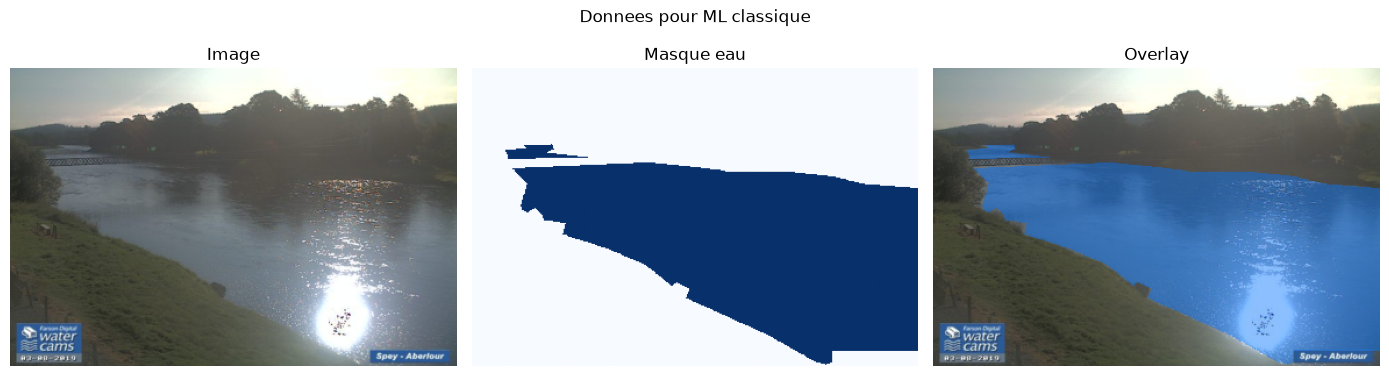

In [2]:
pairs = find_water_v2_pairs(ROOT / "water_v2")
image, mask = load_pair(*pairs[0], size=(384, 256))

pixels = image.reshape(-1, 3)
labels = mask.reshape(-1)

print("X:", pixels.shape)
print("y:", labels.shape)
print("Ratio eau:", labels.mean())
show_image_mask_overlay(image, mask, title="Donnees pour ML classique")

In [3]:
import cv2

FEATURE_COLUMNS = ["Red", "Green", "Blue", "Hue", "Saturation", "Value"]

def image_to_rgb_hsv_dataframe(image: np.ndarray) -> pd.DataFrame:
    """
    Convertit une image RGB en dataframe de features pixel-level.

    Entree
    ------
    image : array de dimensions (H, W, 3)
        Image RGB. Elle peut etre en [0, 1] comme avec load_pair,
        ou en [0, 255] si elle est deja en uint8.

    Sortie
    ------
    X : DataFrame de dimensions (H * W, 6)
        Colonnes : Red, Green, Blue, Hue, Saturation, Value.
    """
    image = np.asarray(image)

    if image.ndim != 3 or image.shape[2] != 3:
        raise ValueError("image doit avoir la forme (H, W, 3).")

    # load_pair retourne une image float en [0, 1]. OpenCV attend uint8 pour HSV.
    if image.dtype != np.uint8:
        image_rgb = (np.clip(image, 0, 1) * 255).astype(np.uint8)
    else:
        image_rgb = image

    image_hsv = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HSV)

    rgb_features = image_rgb.reshape(-1, 3)
    hsv_features = image_hsv.reshape(-1, 3)
    features = np.concatenate([rgb_features, hsv_features], axis=1)

    return pd.DataFrame(features, columns=FEATURE_COLUMNS)


def mask_to_column_vector(mask: np.ndarray) -> np.ndarray:
    """
    Convertit un masque 2D en vecteur colonne.

    Entree : mask de dimensions (H, W)
    Sortie : Y de dimensions (H * W, 1)
    """
    mask = np.asarray(mask)

    if mask.ndim == 3:
        mask = mask.squeeze()

    if mask.ndim != 2:
        raise ValueError("mask doit avoir la forme (H, W).")

    return mask.astype(np.uint8).reshape(-1, 1)


# Exemple sur une image annotee
image, mask = load_pair(*pairs[0], size=(384, 256))

X = image_to_rgb_hsv_dataframe(image)
Y = mask_to_column_vector(mask)

H, W = mask.shape

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)
print("X shape:", X.shape)      # attendu : (H * W, 6)
print("Y shape:", Y.shape)      # attendu : (H * W, 1)

assert X.shape == (H * W, 6)
assert Y.shape == (H * W, 1)

display(X.head())

Image shape: (256, 384, 3)
Mask shape: (256, 384)
X shape: (98304, 6)
Y shape: (98304, 1)


,Red,Green,Blue,Hue,Saturation,Value
0,128,145,152,99,40,152
1,129,146,153,99,40,153
2,129,147,154,98,41,154
3,129,148,154,97,41,154
4,130,149,155,97,41,155


## Construction du dataset pixel-level

On construit maintenant un dataset supervise pixel par pixel.

Pour chaque paire `(image, mask)` :

- `X_img` contient les features RGB + HSV de tous les pixels de l'image ;
- `Y_img` contient les labels du masque correspondant ;
- la ligne `i` de `X_img` correspond toujours a la ligne `i` de `Y_img`.

Ensuite, on concatene toutes les images dans le meme ordre pour obtenir :

- `X_all` de dimensions `(nombre_total_pixels, 6)` ;
- `Y_all` de dimensions `(nombre_total_pixels, 1)`.

In [ ]:
def build_pixel_level_dataset(
    pairs,
    size=(384, 256),
    max_images=None,
    max_pixels_per_image=None,
    seed=42,
) -> None:
    """
    Construit X_all et Y_all a partir de plusieurs paires image/masque.

    Important : l'ordre est conserve.
    La ligne k de X_all correspond exactement a la ligne k de Y_all.

    Parametres
    ----------
    pairs : list[(image_path, mask_path)]
        Paires image/masque retournees par find_water_v2_pairs.

    size : tuple
        Taille commune utilisee pour redimensionner image et masque.

    max_images : int ou None
        Nombre maximal d'images a utiliser. Mettre None pour utiliser toutes les images.

    max_pixels_per_image : int ou None
        Si None, on garde tous les pixels de chaque image.
        Si un entier est donne, on echantillonne ce nombre de pixels par image.
        C'est utile pour eviter un dataset trop lourd en memoire.

    Retour
    ------
    X_all : DataFrame, shape = (N, 6)
    Y_all : ndarray, shape = (N, 1)
    dataset_index : DataFrame
        Table indiquant quelles lignes de X_all/Y_all viennent de quelle image.
    """
    rng = np.random.default_rng(seed)

    selected_pairs = pairs if max_images is None else pairs[:max_images]

    X_parts = []
    Y_parts = []
    index_rows = []
    start_row = 0

    for image_index, (image_path, mask_path) in enumerate(selected_pairs):
        image, mask = load_pair(image_path, mask_path, size=size)

        X_img = image_to_rgb_hsv_dataframe(image)
        Y_img = mask_to_column_vector(mask)

        if len(X_img) != len(Y_img):
            raise ValueError(f"Nombre de pixels different pour {image_path.name} et son masque.")

        if max_pixels_per_image is not None and max_pixels_per_image < len(Y_img):
            sampled_indices = rng.choice(len(Y_img), size=max_pixels_per_image, replace=False)
            sampled_indices.sort()  # garde un ordre stable dans l'image
            X_img = X_img.iloc[sampled_indices].reset_index(drop=True)
            Y_img = Y_img[sampled_indices]

        X_parts.append(X_img)
        Y_parts.append(Y_img)

        end_row = start_row + len(Y_img)
        index_rows.append(
            {
                "image_index": image_index,
                "image_path": str(image_path),
                "mask_path": str(mask_path),
                "start_row": start_row,
                "end_row": end_row,
                "num_pixels": len(Y_img),
                "water_ratio": float(Y_img.mean()),
            }
        )
        start_row = end_row

    X_all = pd.concat(X_parts, ignore_index=True)
    Y_all = np.vstack(Y_parts).astype(np.uint8)
    dataset_index = pd.DataFrame(index_rows)

    return X_all, Y_all, dataset_index

In [ ]:
# Pour un premier test, on peut commencer avec un nombre limite d'images.
# Si la RAM le permet, mettre MAX_IMAGES = None pour utiliser tout water_v2.
# Attention : toutes les images avec tous les pixels peuvent produire un dataset tres grand.

SIZE = (384, 256)
MAX_IMAGES = 20
MAX_PIXELS_PER_IMAGE = None  # None = garder tous les pixels de chaque image selectionnee

X_all, Y_all, dataset_index = build_pixel_level_dataset(
    pairs,
    size=SIZE,
    max_images=MAX_IMAGES,
    max_pixels_per_image=MAX_PIXELS_PER_IMAGE,
    seed=42,
) # type: ignore

print("X_all shape:", X_all.shape)  # attendu : (N, 6)
print("Y_all shape:", Y_all.shape)  # attendu : (N, 1)
print("Ratio eau global:", float(Y_all.mean()))

assert X_all.shape[0] == Y_all.shape[0]
assert X_all.shape[1] == 6
assert Y_all.shape[1] == 1

display(X_all.head())
display(dataset_index.head())

X_all shape: (1966080, 6)
Y_all shape: (1966080, 1)
Ratio eau global: 0.2897883097330729


,Red,Green,Blue,Hue,Saturation,Value
0,128,145,152,99,40,152
1,129,146,153,99,40,153
2,129,147,154,98,41,154
3,129,148,154,97,41,154
4,130,149,155,97,41,155


,image_index,image_path,mask_path,start_row,end_row,num_pixels,water_ratio
0,0,c:\Users\PC\Desktop\water-detection-methods\wa...,c:\Users\PC\Desktop\water-detection-methods\wa...,0,98304,98304,0.391591
1,1,c:\Users\PC\Desktop\water-detection-methods\wa...,c:\Users\PC\Desktop\water-detection-methods\wa...,98304,196608,98304,0.388936
2,2,c:\Users\PC\Desktop\water-detection-methods\wa...,c:\Users\PC\Desktop\water-detection-methods\wa...,196608,294912,98304,0.391398
3,3,c:\Users\PC\Desktop\water-detection-methods\wa...,c:\Users\PC\Desktop\water-detection-methods\wa...,294912,393216,98304,0.396444
4,4,c:\Users\PC\Desktop\water-detection-methods\wa...,c:\Users\PC\Desktop\water-detection-methods\wa...,393216,491520,98304,0.392680


## Train/test split

On separe maintenant les pixels en train et test.

Pour `scikit-learn`, le vecteur `y` doit souvent etre de forme `(N,)`, donc on utilise `Y_all.ravel()` pour l'entrainement.

Remarque importante : ce split est un split pixel-level. Pour une evaluation plus stricte, on pourra plus tard faire un split image-level, c'est-a-dire entrainer sur certaines images et tester sur d'autres images jamais vues.

In [ ]:
from sklearn.model_selection import train_test_split

y_all = Y_all.ravel()

X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all,
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)
#print("Ratio eau train:", y_train.mean())
#print("Ratio eau test :", y_test.mean())

X_train: (1572864, 6)
X_test : (393216, 6)
y_train: (1572864,)
y_test : (393216,)
Ratio eau train: 0.28978856404622394
Ratio eau test : 0.28978729248046875
